# NB3: 统计驱动策略

## 研究假设
> NB2证明了经典技术指标在BTC市场上难以跑赢买入持有。本Notebook换一个思路：不依赖固定阈值的指标信号，而是用统计方法捕捉价格偏离均值后的回归机会。核心假设是"涨多了会跌，跌多了会涨"。

## 决策日志
| 决策 | 选择 | 为什么 |
|------|------|--------|
| 策略方向 | 均值回归 | NB2的趋势跟踪策略全部失败，尝试反向逻辑 |
| 衡量偏离 | Z-score | 标准化后可跨时间段对比，不受价格绝对值影响 |
| 回归基准 | 滚动均值 | 用动态均值而非全局均值，适应市场结构变化 |
| 与NB2的区别 | 统计驱动 vs 规则驱动 | 不设固定阈值，让数据说话 |

---
## 1. 加载数据

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import json
import warnings

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei']
matplotlib.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_parquet('../data/btc_usdt_1h_clean.parquet')
with open('../data/config.json', 'r') as f:
    CONFIG = json.load(f)

print(f"已加载: {len(df):,} 条 {CONFIG['symbol']} {CONFIG['timeframe']} K线")

已加载: 35,064 条 BTC/USDT 1h K线


---
## 2. Z-score均值回归策略

思路：计算价格相对于滚动均值的Z-score（偏离了多少个标准差）。Z-score越负说明超跌越严重，买入；Z-score越正说明超涨，卖出。

In [2]:
def zscore_strategy(df, window=168, entry_z=-2, exit_z=0):
    """
    Z-score均值回归策略
    - window: 滚动窗口（168 = 7天）
    - entry_z: 入场阈值（Z-score低于此值买入）
    - exit_z: 出场阈值（Z-score回归到此值平仓）
    """
    data = df.copy()
    
    data['rolling_mean'] = data['close'].rolling(window).mean()
    data['rolling_std'] = data['close'].rolling(window).std()
    data['zscore'] = (data['close'] - data['rolling_mean']) / data['rolling_std']
    
    data['signal'] = np.nan
    data.loc[data['zscore'] <= entry_z, 'signal'] = 1.0    # 超跌买入
    data.loc[data['zscore'] >= exit_z, 'signal'] = 0.0     # 回归平仓
    
    data['signal'] = data['signal'].ffill().fillna(0)
    
    return data

df_zs = zscore_strategy(df)
print(f"Z-score策略 (窗口7天, 入场Z<=-2, 出场Z>=0)")
print(f"仓位分布:")
print(df_zs['signal'].value_counts().sort_index())

Z-score策略 (窗口7天, 入场Z<=-2, 出场Z>=0)
仓位分布:
signal
0.0    25439
1.0     9625
Name: count, dtype: int64


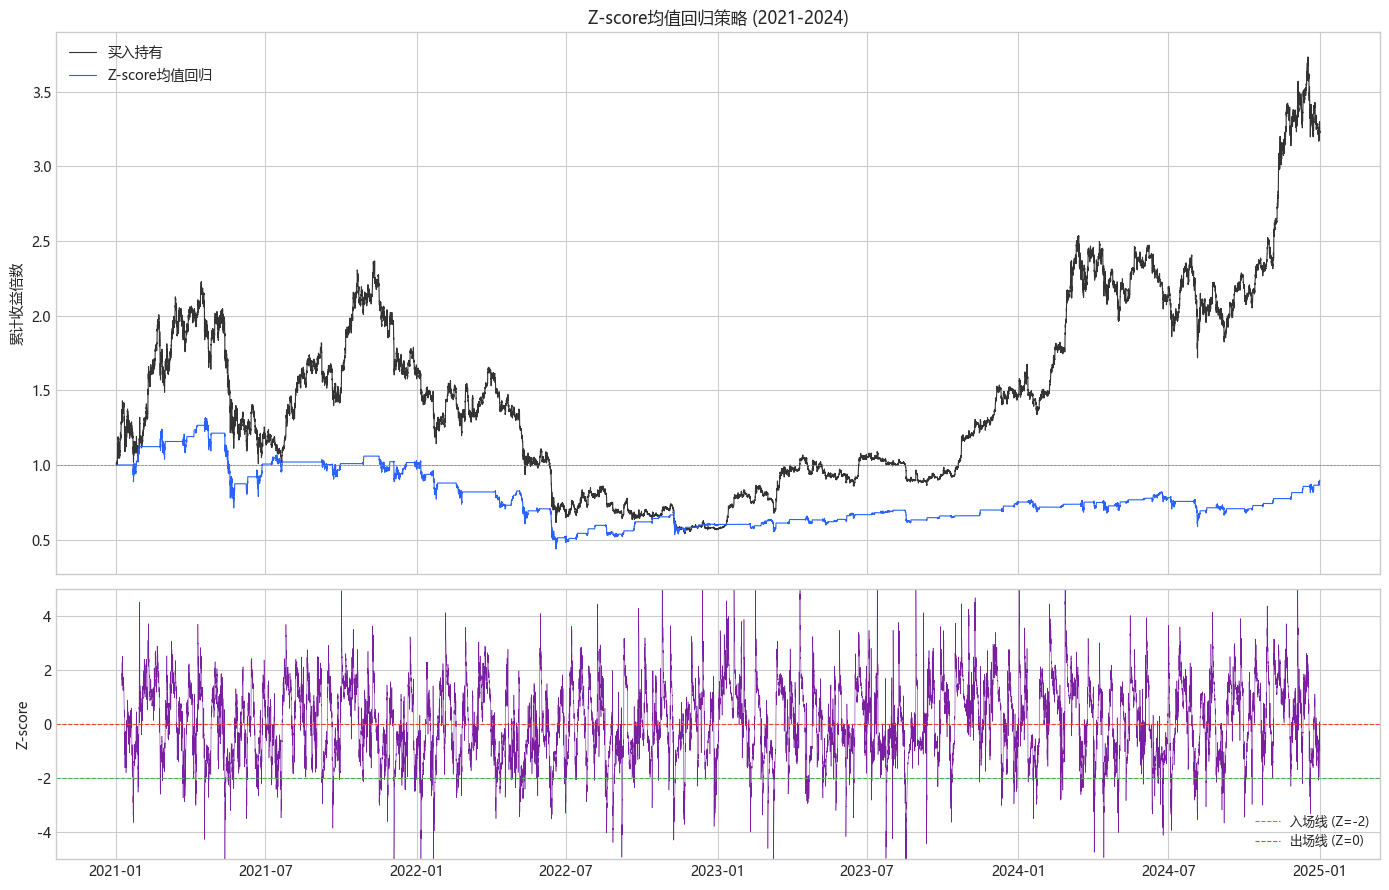

,总收益,年化收益,年化波动,夏普比率,最大回撤,胜率
策略,,,,,,
买入持有,218.2%,33.5%,63.3%,0.53,-77.2%,50.7%
Z-score均值回归,-10.2%,-2.7%,39.0%,-0.07,-66.8%,50.2%


In [5]:
def backtest_sized(df, fee=0.001):
    """支持分仓的回测"""
    data = df.copy()
    data['strategy_returns'] = data['signal'].shift(1) * data['returns']
    position_change = data['signal'].diff().abs()
    data['strategy_returns'] -= position_change * fee
    data['cumulative_market'] = (1 + data['returns']).cumprod()
    data['cumulative_strategy'] = (1 + data['strategy_returns']).cumprod()
    return data

def calc_metrics(data, strategy_name):
    """计算核心绩效指标"""
    ret = data['strategy_returns'].dropna()
    cum = data['cumulative_strategy'].dropna()
    total_return = cum.iloc[-1] / cum.iloc[0] - 1
    annual_return = (1 + total_return) ** (8760 / len(ret)) - 1
    annual_vol = ret.std() * np.sqrt(8760)
    sharpe = annual_return / annual_vol if annual_vol != 0 else 0
    peak = cum.cummax()
    drawdown = (cum - peak) / peak
    max_drawdown = drawdown.min()
    trades = ret[ret != 0]
    win_rate = (trades > 0).sum() / len(trades) if len(trades) > 0 else 0
    return {
        '策略': strategy_name,
        '总收益': f"{total_return:.1%}",
        '年化收益': f"{annual_return:.1%}",
        '年化波动': f"{annual_vol:.1%}",
        '夏普比率': f"{sharpe:.2f}",
        '最大回撤': f"{max_drawdown:.1%}",
        '胜率': f"{win_rate:.1%}",
    }

df_zs_bt = backtest_sized(df_zs)

# 买入持有基准
df_hold = df.copy()
df_hold['strategy_returns'] = df_hold['returns']
df_hold['cumulative_strategy'] = (1 + df_hold['returns']).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})

axes[0].plot(df_zs_bt.index, df_zs_bt['cumulative_market'], linewidth=0.8, color='#333', label='买入持有')
axes[0].plot(df_zs_bt.index, df_zs_bt['cumulative_strategy'], linewidth=0.8, color='#2962FF', label='Z-score均值回归')
axes[0].axhline(1, color='gray', linestyle='--', linewidth=0.5)
axes[0].set_ylabel('累计收益倍数')
axes[0].set_title('Z-score均值回归策略 (2021-2024)')
axes[0].legend()

axes[1].plot(df_zs.index, df_zs['zscore'], linewidth=0.4, color='#7B1FA2')
axes[1].axhline(-2, color='#4CAF50', linestyle='--', linewidth=0.8, label='入场线 (Z=-2)')
axes[1].axhline(0, color='#F44336', linestyle='--', linewidth=0.8, label='出场线 (Z=0)')
axes[1].set_ylabel('Z-score')
axes[1].set_ylim(-5, 5)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

results = [
    calc_metrics(df_hold, '买入持有'),
    calc_metrics(df_zs_bt, 'Z-score均值回归'),
]
pd.DataFrame(results).set_index('策略')

---
## 3. 参数敏感性分析

用不同的窗口期和入场Z-score阈值做网格搜索，找到最优参数组合。

In [6]:
windows = [72, 168, 336, 720]       # 3天、7天、14天、30天
entry_zs = [-1.0, -1.5, -2.0, -2.5]

results_grid = []

for w in windows:
    for z in entry_zs:
        df_test = zscore_strategy(df, window=w, entry_z=z, exit_z=0)
        df_test_bt = backtest_sized(df_test)
        
        cum = df_test_bt['cumulative_strategy'].dropna()
        total_ret = cum.iloc[-1] / cum.iloc[0] - 1
        
        ret = df_test_bt['strategy_returns'].dropna()
        annual_vol = ret.std() * np.sqrt(8760)
        annual_ret = (1 + total_ret) ** (8760 / len(ret)) - 1
        sharpe = annual_ret / annual_vol if annual_vol != 0 else 0
        
        peak = cum.cummax()
        max_dd = ((cum - peak) / peak).min()
        
        hold_pct = (df_test['signal'] == 1).mean()
        
        results_grid.append({
            '窗口': f"{w}h ({w//24}天)",
            '入场Z': z,
            '总收益': f"{total_ret:.1%}",
            '夏普': f"{sharpe:.2f}",
            '最大回撤': f"{max_dd:.1%}",
            '持仓占比': f"{hold_pct:.0%}",
        })

pd.DataFrame(results_grid)

,窗口,入场Z,总收益,夏普,最大回撤,持仓占比
0,72h (3天),-1.0,-62.2%,-0.50,-67.9%,39%
1,72h (3天),-1.5,-58.7%,-0.47,-64.7%,34%
2,72h (3天),-2.0,-54.8%,-0.45,-62.9%,30%
3,72h (3天),-2.5,-49.6%,-0.42,-62.0%,25%
4,168h (7天),-1.0,-15.5%,-0.09,-59.6%,38%
5,168h (7天),-1.5,35.3%,0.19,-49.8%,34%
6,168h (7天),-2.0,-10.2%,-0.07,-66.8%,27%
7,168h (7天),-2.5,-28.5%,-0.22,-65.5%,22%
8,336h (14天),-1.0,-27.5%,-0.18,-67.1%,38%
9,336h (14天),-1.5,-34.8%,-0.24,-67.9%,33%


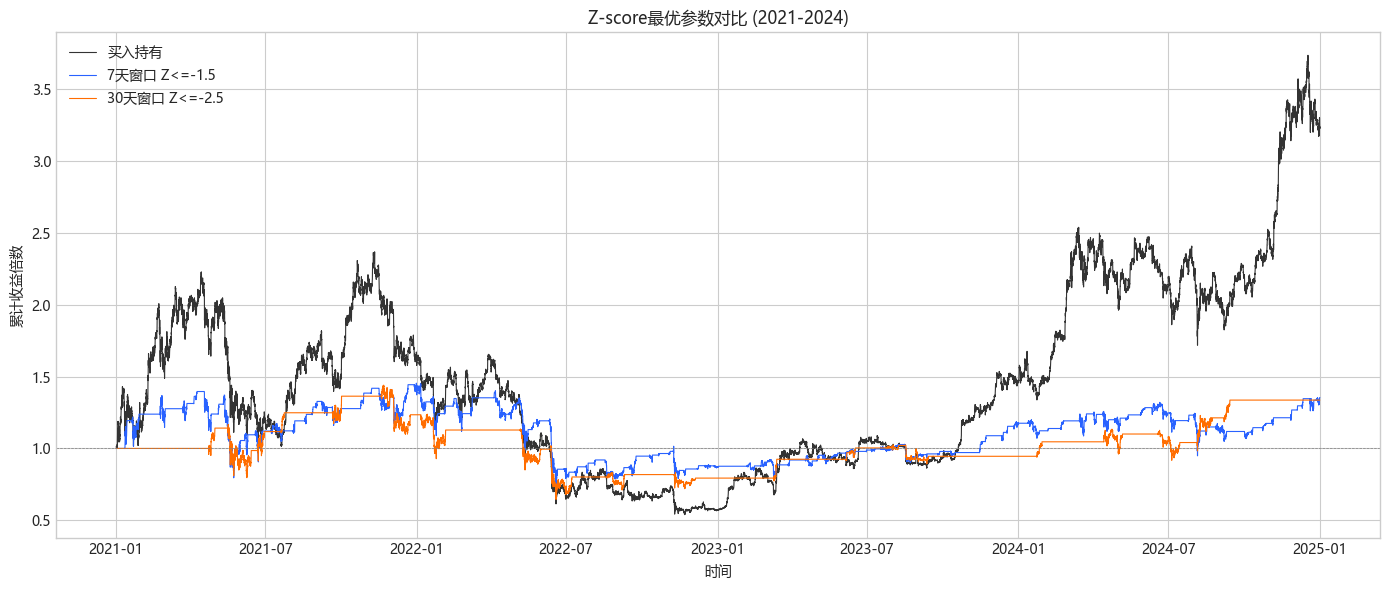

,总收益,年化收益,年化波动,夏普比率,最大回撤,胜率
策略,,,,,,
买入持有,218.2%,33.5%,63.3%,0.53,-77.2%,50.7%
7天 Z<=-1.5,35.3%,7.8%,41.9%,0.19,-49.8%,50.4%
30天 Z<=-2.5,33.6%,7.5%,36.9%,0.20,-55.2%,50.2%


In [7]:
df_best1 = zscore_strategy(df, window=168, entry_z=-1.5, exit_z=0)
df_best1_bt = backtest_sized(df_best1)

df_best2 = zscore_strategy(df, window=720, entry_z=-2.5, exit_z=0)
df_best2_bt = backtest_sized(df_best2)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_best1_bt.index, df_best1_bt['cumulative_market'], linewidth=0.8, color='#333', label='买入持有')
ax.plot(df_best1_bt.index, df_best1_bt['cumulative_strategy'], linewidth=0.8, color='#2962FF', label='7天窗口 Z<=-1.5')
ax.plot(df_best2_bt.index, df_best2_bt['cumulative_strategy'], linewidth=0.8, color='#FF6D00', label='30天窗口 Z<=-2.5')

ax.axhline(1, color='gray', linestyle='--', linewidth=0.5)
ax.set_title('Z-score最优参数对比 (2021-2024)')
ax.set_ylabel('累计收益倍数')
ax.set_xlabel('时间')
ax.legend()
plt.tight_layout()
plt.show()

results = [
    calc_metrics(df_hold, '买入持有'),
    calc_metrics(df_best1_bt, '7天 Z<=-1.5'),
    calc_metrics(df_best2_bt, '30天 Z<=-2.5'),
]
pd.DataFrame(results).set_index('策略')

---
## 4. 改进：Z-score连续仓位

不再用固定阈值做开关，而是让仓位随Z-score连续变化。Z-score越负仓位越高，越正仓位越低。

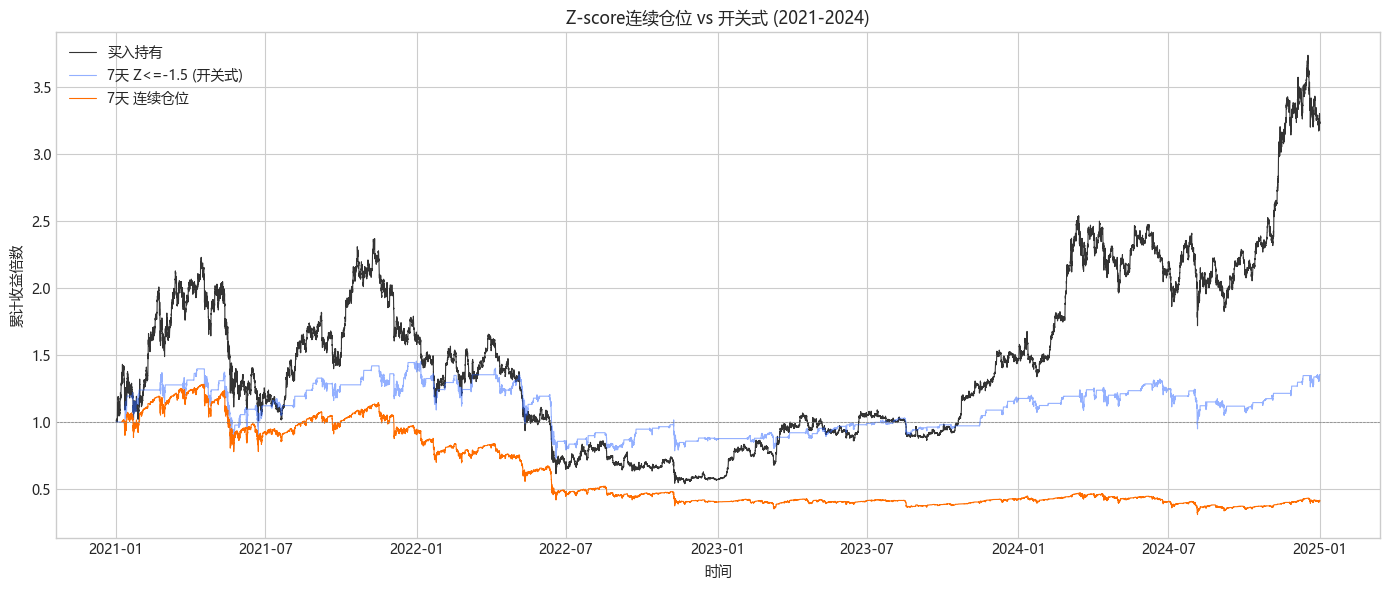

,总收益,年化收益,年化波动,夏普比率,最大回撤,胜率
策略,,,,,,
买入持有,218.2%,33.5%,63.3%,0.53,-77.2%,50.7%
7天 开关式,35.3%,7.8%,41.9%,0.19,-49.8%,50.4%
7天 连续仓位,-58.9%,-20.0%,41.0%,-0.49,-75.9%,50.1%


In [8]:
def zscore_continuous(df, window=168):
    """Z-score连续仓位策略"""
    data = df.copy()
    
    data['rolling_mean'] = data['close'].rolling(window).mean()
    data['rolling_std'] = data['close'].rolling(window).std()
    data['zscore'] = (data['close'] - data['rolling_mean']) / data['rolling_std']
    
    # Z-score映射到仓位：Z<=-2 -> 100%, Z=0 -> 50%, Z>=2 -> 0%
    # 线性映射：仓位 = 0.5 - Z/4，裁剪到[0, 1]
    data['signal'] = (0.5 - data['zscore'] / 4).clip(0, 1)
    
    return data

df_cont = zscore_continuous(df, window=168)
df_cont_bt = backtest_sized(df_cont)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_cont_bt.index, df_cont_bt['cumulative_market'], linewidth=0.8, color='#333', label='买入持有')
ax.plot(df_best1_bt.index, df_best1_bt['cumulative_strategy'], linewidth=0.8, color='#2962FF', alpha=0.5, label='7天 Z<=-1.5 (开关式)')
ax.plot(df_cont_bt.index, df_cont_bt['cumulative_strategy'], linewidth=0.8, color='#FF6D00', label='7天 连续仓位')

ax.axhline(1, color='gray', linestyle='--', linewidth=0.5)
ax.set_title('Z-score连续仓位 vs 开关式 (2021-2024)')
ax.set_ylabel('累计收益倍数')
ax.set_xlabel('时间')
ax.legend()
plt.tight_layout()
plt.show()

results = [
    calc_metrics(df_hold, '买入持有'),
    calc_metrics(df_best1_bt, '7天 开关式'),
    calc_metrics(df_cont_bt, '7天 连续仓位'),
]
pd.DataFrame(results).set_index('策略')

平均仓位: 75%


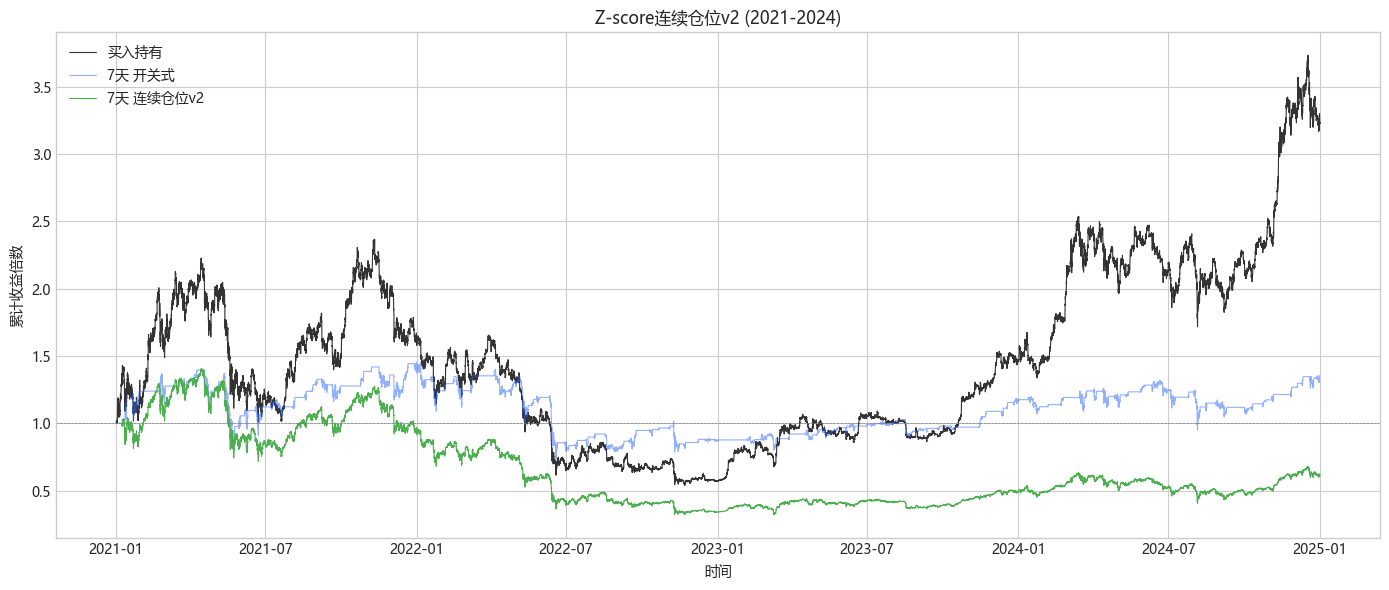

,总收益,年化收益,年化波动,夏普比率,最大回撤,胜率
策略,,,,,,
买入持有,218.2%,33.5%,63.3%,0.53,-77.2%,50.7%
7天 开关式,35.3%,7.8%,41.9%,0.19,-49.8%,50.4%
7天 连续仓位v2,-38.5%,-11.5%,51.7%,-0.22,-77.2%,50.5%


In [9]:
def zscore_continuous_v2(df, window=168):
    """Z-score连续仓位v2：基础仓位高，只在极端超涨时减仓"""
    data = df.copy()
    
    data['rolling_mean'] = data['close'].rolling(window).mean()
    data['rolling_std'] = data['close'].rolling(window).std()
    data['zscore'] = (data['close'] - data['rolling_mean']) / data['rolling_std']
    
    # Z<=-2: 100%, Z=0: 80%, Z=2: 40%, Z>=3: 0%
    data['signal'] = (0.8 - data['zscore'] * 0.2).clip(0, 1)
    
    return data

df_cont2 = zscore_continuous_v2(df, window=168)
df_cont2_bt = backtest_sized(df_cont2)

print(f"平均仓位: {df_cont2['signal'].mean():.0%}")

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_cont2_bt.index, df_cont2_bt['cumulative_market'], linewidth=0.8, color='#333', label='买入持有')
ax.plot(df_best1_bt.index, df_best1_bt['cumulative_strategy'], linewidth=0.8, color='#2962FF', alpha=0.5, label='7天 开关式')
ax.plot(df_cont2_bt.index, df_cont2_bt['cumulative_strategy'], linewidth=0.8, color='#4CAF50', label='7天 连续仓位v2')

ax.axhline(1, color='gray', linestyle='--', linewidth=0.5)
ax.set_title('Z-score连续仓位v2 (2021-2024)')
ax.set_ylabel('累计收益倍数')
ax.set_xlabel('时间')
ax.legend()
plt.tight_layout()
plt.show()

results = [
    calc_metrics(df_hold, '买入持有'),
    calc_metrics(df_best1_bt, '7天 开关式'),
    calc_metrics(df_cont2_bt, '7天 连续仓位v2'),
]
pd.DataFrame(results).set_index('策略')